# Practical Homework 1: Decision Trees

## Introduction
- This analysis examines factors associated with youth alcohol, specifically the question: *What factors are associated with youth alcohol use, and how frequently do youth engage in alcohol usage?*
    - To address this question, alcohol use is examined in three different forms: whether a youth has ever used alcohol, how frequently they use alcohol, and how many days they use alcohol over the course of a year.
- The data used is from the National Survey on Drug Use and Health (NSDUH).
    - The dataset used in this analysis is a pre-processed subset of the NSDUH data, filtered to include only respondents under the age of 18. It includes variables related to demographics, peer influence, family environment, school experiences, and substance use. Many variables are coded in multiple ways (binary, categorical, and numeric), allowing for comparison of how different representations of the same concept affect model performance.
- To investigate these questions, several tree-based machine learning methods are used. These include decision trees as baseline models, along with ensemble methods such as random forests, gradient boosting, and bagging. These methods are applied to three types of problems: binary classification, multi-class classification, and regression.

## Import and Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingRegressor, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error

## Load and Inspect Data

### Loading and general inspection

In [125]:
df = pd.read_csv("youth_data.csv")

df.head()

,IRALCFY,IRMJFY,IRCIGFM,IRSMKLSS30N,IRALCFM,IRMJFM,IRCIGAGE,IRSMKLSSTRY,IRALCAGE,IRMJAGE,...,EDUSCHLGO,EDUSCHGRD2,EDUSKPCOM,IMOTHER,IFATHER,INCOME,GOVTPROG,POVERTY3,PDEN10,COUTYP4
0,991,991,91.0,91,91.0,91.0,991,991,991,991,...,1,3,0,1,1,2,2,1,2,2
1,991,60,91.0,91,91.0,2.0,991,991,991,14,...,1,6,0,1,1,2,2,1,2,2
2,1,991,91.0,91,93.0,91.0,991,991,11,991,...,1,2,1,1,1,4,2,3,1,1
3,991,991,91.0,91,91.0,91.0,991,991,991,991,...,1,2,0,1,1,3,2,2,1,1
4,991,991,91.0,91,91.0,91.0,991,991,991,991,...,1,5,0,1,1,4,2,3,2,2


In [126]:
print("Dataset info:")
df.info()

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10561 entries, 0 to 10560
Data columns (total 79 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   IRALCFY      10561 non-null  int64  
 1   IRMJFY       10561 non-null  int64  
 2   IRCIGFM      10561 non-null  float64
 3   IRSMKLSS30N  10561 non-null  int64  
 4   IRALCFM      10561 non-null  float64
 5   IRMJFM       10561 non-null  float64
 6   IRCIGAGE     10561 non-null  int64  
 7   IRSMKLSSTRY  10561 non-null  int64  
 8   IRALCAGE     10561 non-null  int64  
 9   IRMJAGE      10561 non-null  int64  
 10  MRJFLAG      10561 non-null  int64  
 11  ALCFLAG      10561 non-null  int64  
 12  TOBFLAG      10561 non-null  int64  
 13  ALCYDAYS     10561 non-null  int64  
 14  MRJYDAYS     10561 non-null  int64  
 15  ALCMDAYS     10561 non-null  int64  
 16  MRJMDAYS     10561 non-null  int64  
 17  CIGMDAYS     10561 non-null  int64  
 18  SMKLSMDAYS   10561 non-null  int

In [ ]:
missing_counts = df.isna().sum().sort_values(ascending = False)

missing_counts.head(15)

AVGGRADE    716
STNDDNK     550
STNDALC     454
STNDSMJ     445
STNDSCIG    377
TALKPROB    336
RLGFRND     322
RLGIMPT     321
RLGDCSN     297
RLGATTD     288
PRBSOLV2    286
PARLMTSN    259
PRTALK3     199
DRPRVME3    193
ARGUPAR     180
dtype: int64

### Key variable inspection

#### Alcohol Usage
- Alcohol - Ever Used (ALCFLAG)
    - 0 = Never used (IRALCRC = 9)
    - 1 = Used within the past year (IRALCRC = 1, 2)

In [57]:
print("ALCFLAG value counts:")

print(df['ALCFLAG'].value_counts(dropna = False))

ALCFLAG value counts:
ALCFLAG
0    8157
1    2404
Name: count, dtype: int64


#### Alcohol Frequency
- ALCOHOL FREQUENCY PAST MONTH - IMPUTATION REVISED (IRALCFM)
    - Range = 1 - 30
    - 91 = Never Used
    - 93 = Did not Use Alcohol Past Month

In [58]:
print("IRALCFM value counts:")

print(df['IRALCFM'].value_counts(dropna = False).sort_index())

IRALCFM value counts:
IRALCFM
1.0      281
1.5       10
2.0      166
3.0      101
4.0       52
5.0       46
6.0        9
7.0       14
7.5        1
8.0        5
9.0        2
10.0      18
11.0       1
12.0       6
14.0       2
15.0       9
16.0       2
17.0       1
20.0       1
21.0       1
27.0       1
28.0       2
30.0       3
91.0    8157
93.0    1670
Name: count, dtype: int64


#### Alcohol Frequency (2)
- ALCOHOL FREQUENCY PAST YEAR - IMPUTATION REVISED (IRALCFY)
    - Range = 1- 365
    - 991 = NEVER USED ALCOHOL
    - 993 = DID NOT USE ALCOHOL IN THE PAST 12 MOS


In [59]:
print("IRALCFY value counts (top 15):")
print(df['IRALCFY'].value_counts(dropna = False).head(15))

IRALCFY value counts (top 15):
IRALCFY
991    8157
993     539
1       326
2       221
3       190
5       121
12      113
24       99
52       90
4        87
36       71
6        54
48       43
10       40
8        38
Name: count, dtype: int64


## Data Cleaning and Preparation

In [60]:
df_clean = df.copy()

### Special Codes
- The codes listed will be recored so that nouse is represented as 0 and invalid responses are treated as missing.
- `IRALCFM`
    - 91 = Never used alcohol > 0
    - 93 = Did not use alcohol in the past month > 0
- `IRALCFY`
    - 991 = Never used alcohol > 0
    - 993 = Did not use alcohol in the past 12 months > 0

#### Alcohol Frequency Past Month (IRALCFM)

In [61]:
df_clean['IRALCFM'] = df_clean['IRALCFM'].replace({
    91: 0,   # never used alcohol
    93: 0    # did not use alcohol past month
})

print(df_clean['IRALCFM'].value_counts(dropna = False).sort_index())
df_clean['IRALCFM'].describe()

IRALCFM
0.0     9827
1.0      281
1.5       10
2.0      166
3.0      101
4.0       52
5.0       46
6.0        9
7.0       14
7.5        1
8.0        5
9.0        2
10.0      18
11.0       1
12.0       6
14.0       2
15.0       9
16.0       2
17.0       1
20.0       1
21.0       1
27.0       1
28.0       2
30.0       3
Name: count, dtype: int64


count    10561.000000
mean         0.215463
std          1.259715
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         30.000000
Name: IRALCFM, dtype: float64

#### Alcohol Frequency Past Year (IRALCFY)

In [ ]:
df_clean['IRALCFY'] = df_clean['IRALCFY'].replace({
    991: 0,
    993: 0
})

print(df_clean['IRALCFY'].value_counts(dropna = False).sort_index().head(15))
df_clean['IRALCFY'].describe()

IRALCFY
0     8696
1      326
2      221
3      190
4       87
5      121
6       54
7       27
8       38
9       12
10      40
11      10
12     113
13      10
14      10
Name: count, dtype: int64


count    10561.000000
mean         3.958243
std         18.975554
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        339.000000
Name: IRALCFY, dtype: float64

### Binary Target Variable
- ALCFLAG indicates whether a respondent has ever used alcohol. This does not need recoding.

In [63]:
df_clean['ALCFLAG'].value_counts(dropna = False)

ALCFLAG
0    8157
1    2404
Name: count, dtype: int64

### Multi-class Target Variable
- IRALCFM needs to be converted into categorical levels representing frequency of alcohol use.
    - 0 = No use
    - 1 = Low use (1–5 days)
    - 2 = Moderate use (6–15 days)
    - 3 = High use (16–30 days)


In [64]:
def categorize_alc_freq(x):
    if x == 0:
        return 0
    elif 1 <= x <= 5:
        return 1
    elif 6 <= x <= 15:
        return 2
    elif 16 <= x <= 30:
        return 3
    else:
        return np.nan

df_clean['ALC_FREQ_CAT'] = df_clean['IRALCFM'].apply(categorize_alc_freq)

df_clean['ALC_FREQ_CAT'].value_counts(dropna = False).sort_index()

ALC_FREQ_CAT
0    9827
1     656
2      67
3      11
Name: count, dtype: int64

### Predictor Selection and modeling dataset
These are a reasonable first set because they reflect:

demographics
family environment
peer influence
school norms
behavior

and they avoid direct alcohol-use leakage.

In [71]:
predictors = [
    'IRSEX', 'NEWRACE2', 'INCOME', 'POVERTY3',
    'PARCHKHW', 'PARHLPHW', 'PRPROUD2',
    'AVGGRADE', 'STNDALC', 'STNDSMJ',
    'FRDADLY2', 'FRDMJMON',
    'YOFIGHT2', 'YOSTOLE2'
]

model_vars = predictors + ['ALCFLAG', 'IRALCFM', 'ALC_FREQ_CAT', 'IRALCFY']

model_data = df_clean[model_vars].dropna()

print("Modeling dataset shape:", model_data.shape)

Modeling dataset shape: (9227, 18)


In [ ]:
# Define the predictor matrix and target variables
X = model_data[predictors]

y_binary = model_data['ALCFLAG']

y_multi = model_data['ALC_FREQ_CAT']
y_reg = model_data['IRALCFY']

## Binary Classification Model
In this section, I build classification models to predict whether a youth has ever used alcohol. The target variable is `ALCFLAG`, where 0 indicates never used alcohol and 1 indicates ever used alcohol.

I begin with a single decision tree as a baseline model, then compare it to a random forest to see whether an ensemble method improves predictive performance.

To evaluate the models, I use:
- Accuracy
- Confusion matrices
- Feature importance

### Single Decision Tree

In [75]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size = 0.3, random_state = 1
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (6458, 14)
Test set size: (2769, 14)


In [ ]:
# Create a baseline decision tree classifier
tree_clf = DecisionTreeClassifier(random_state = 1)

# Fit the model on the training data
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

In [77]:
# Generate predictions on the test set
y_pred_tree = tree_clf.predict(X_test)

# Calculate accuracy of the decision tree model
tree_acc = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", round(tree_acc, 4))

Decision Tree Accuracy: 0.7551


In [78]:
# Create confusion matrix
tree_cm = confusion_matrix(y_test, y_pred_tree)

print("Decision Tree Confusion Matrix:")
print(tree_cm)

Decision Tree Confusion Matrix:
[[1862  237]
 [ 441  229]]


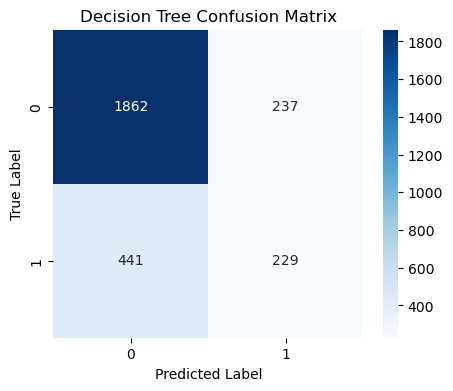

In [ ]:
# Plot the confusion matrix as a heatmap
plt.figure(figsize = (5, 4))
sns.heatmap(tree_cm, annot = True, fmt = 'd', cmap = 'Blues')

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

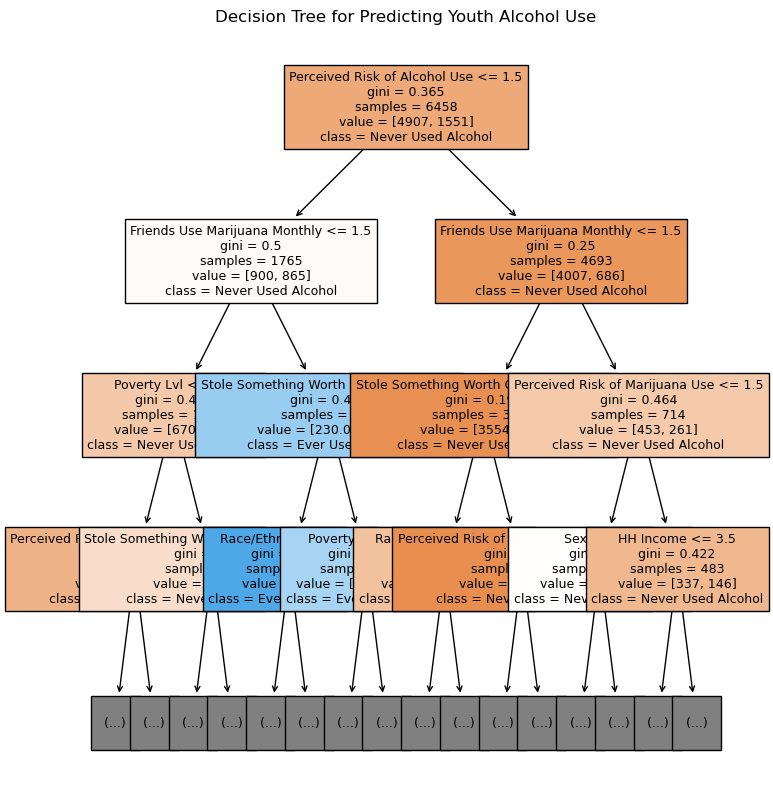

In [128]:
names = {
    'IRSEX': 'Sex',
    'NEWRACE2': 'Race/Ethnicity',
    'INCOME': 'HH Income',
    'POVERTY3': 'Poverty Lvl',
    'PARCHKHW': 'Parents Check Homework',
    'PARHLPHW': 'Parents Help with Homework',
    'PRPROUD2': 'Parents Say They Are Proud',
    'AVGGRADE': 'Avg Grade in School',
    'STNDALC': 'Perceived Risk of Alcohol Use',
    'STNDSMJ': 'Perceived Risk of Marijuana Use',
    'FRDADLY2': 'Friends Use Alcohol Daily',
    'FRDMJMON': 'Friends Use Marijuana Monthly',
    'YOFIGHT2': 'Involved in Serious Fight',
    'YOSTOLE2': 'Stole Something Worth Over $50'
}

feature_names = [names[col] for col in X.columns]

plt.figure(figsize = (8, 10))
plot_tree(
    tree_clf,
    feature_names = feature_names,
    class_names = ['Never Used Alcohol', 'Ever Used Alcohol'],
    filled = True,
    max_depth = 3,
    fontsize = 9
)
plt.title("Decision Tree for Predicting Youth Alcohol Use")
plt.show()

### Random Forest

In [ ]:
# Create a random forest classifier with 100 trees
rf_clf = RandomForestClassifier(n_estimators = 100, random_state = 1)

# Fit the model using the training data
rf_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=1)

In [85]:
# Generate predictions on the test set
y_pred_rf = rf_clf.predict(X_test)

In [86]:
# Calculate accuracy for the random forest model
rf_acc = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(rf_acc, 4))

Random Forest Accuracy: 0.7671


In [87]:
# Create the confusion matrix
rf_cm = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[1889  210]
 [ 435  235]]


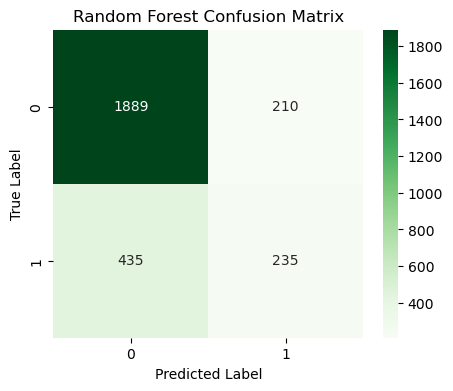

In [ ]:
# Plot the confusion matrix as a heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(rf_cm, annot = True, fmt = 'd', cmap = 'Greens')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size = 0.3, random_state = 1
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (6458, 14)
Test set size: (2769, 14)


In [ ]:
# Extract feature importance values
feature_importance = pd.Series(rf_clf.feature_importances_, index = X.columns)

# Sort from most to least important
feature_importance = feature_importance.sort_values(ascending = False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

Top 10 Most Important Features:
NEWRACE2    0.159755
FRDMJMON    0.124249
STNDALC     0.120316
INCOME      0.095369
STNDSMJ     0.084554
POVERTY3    0.064902
IRSEX       0.060539
PRPROUD2    0.046412
PARCHKHW    0.046173
YOFIGHT2    0.045413
dtype: float64


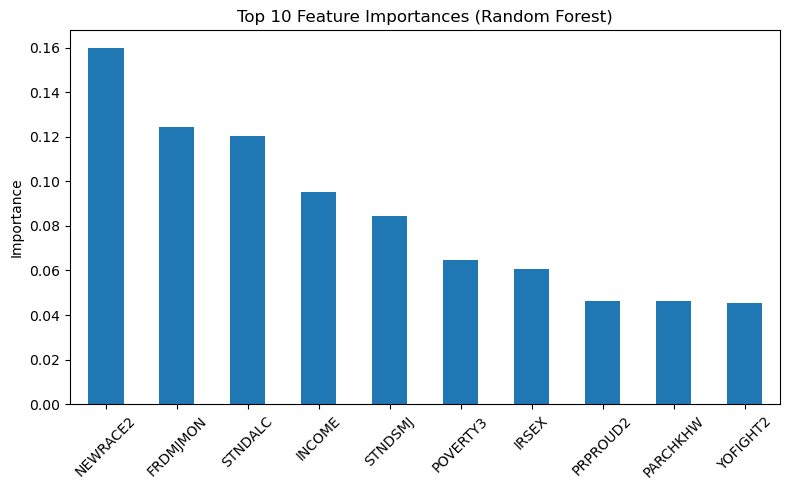

In [ ]:
# Plot top 10 features
plt.figure(figsize = (8, 5))
feature_importance.head(10).plot(kind = 'bar')

plt.title("Top 10 Feature Importances (Random Forest)")
plt.ylabel("Importance")
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

### Summary

In [97]:
# Compare the two binary classification models
print("Decision Tree Accuracy:", round(tree_acc, 4))
print("Random Forest Accuracy:", round(rf_acc, 4))

Decision Tree Accuracy: 0.7551
Random Forest Accuracy: 0.7671


- The decision tree achieved an accuracy of 0.7551, while the random forest achieved an accuracy of 0.7671. Accuracy represents the proportion of correct predictions made by the model, so this means the random forest correctly classified whether a youth had ever used alcohol about 77% of the time.

- The improvement from the random forest was modest, suggesting that while combining multiple trees helped reduce overfitting, the single decision tree already captured much of the underlying pattern in the data.

- The confusion matrices show that both models were better at identifying youth who had never used alcohol than those who had used alcohol indicating that the models are biased toward the majority class.

- Feature importance from the random forest suggests that peer influence, perceived risk of substance use, socioeconomic variables, and family-related variables were among the most important predictors of alcohol use. This highlights that youth alcohol use is associated with a combination of social environment, attitudes, and background factors rather than a single dominant influence.

## Multi-Class Classification Model
In this section, I predict the frequency of youth alcohol use using the categorical target variable `ALC_FREQ_CAT`. This variable was created from `IRALCFM` and groups alcohol use in the past month into four levels:

- 0 = No use
- 1 = Low use (1–5 days)
- 2 = Moderate use (6–15 days)
- 3 = High use (16–30 days)

I begin with a single decision tree classifier as a baseline model and then compare it to a gradient boosting classifier.

### Decision Tree Model

In [ ]:
# Define predictors and multi-class target
X = model_data[predictors]
y_multi = model_data['ALC_FREQ_CAT']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_multi, test_size=0.3, random_state = 1
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (6458, 14)
Test set size: (2769, 14)


In [ ]:
# Create a baseline decision tree classifier for the multi-class problem
tree_multi = DecisionTreeClassifier(random_state = 1)

# Fit the model on the training data
tree_multi.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

In [100]:
# Generate predictions on the test set
y_pred_tree_multi = tree_multi.predict(X_test)

# Calculate accuracy
tree_multi_acc = accuracy_score(y_test, y_pred_tree_multi)

print("Decision Tree Accuracy:", round(tree_multi_acc, 4))

Decision Tree Accuracy: 0.8938


In [101]:
# Create the confusion matrix
tree_multi_cm = confusion_matrix(y_test, y_pred_tree_multi)

print("Decision Tree Confusion Matrix:")
print(tree_multi_cm)

Decision Tree Confusion Matrix:
[[2446  106    3    0]
 [ 157   28    2    1]
 [  16    4    1    0]
 [   3    1    1    0]]


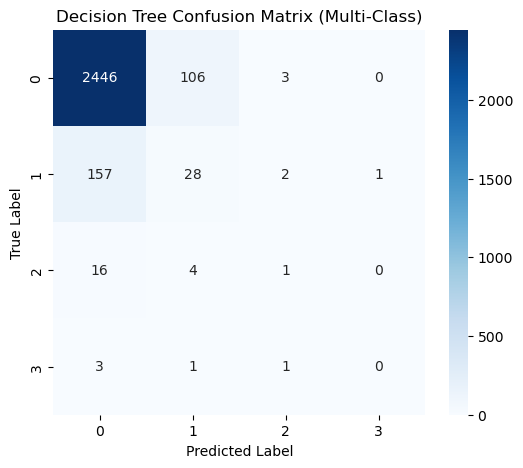

In [ ]:
# Plot the confusion matrix as a heatmap
plt.figure(figsize = (6, 5))
sns.heatmap(tree_multi_cm, annot = True, fmt = 'd', cmap = 'Blues')

plt.title("Decision Tree Confusion Matrix (Multi-Class)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

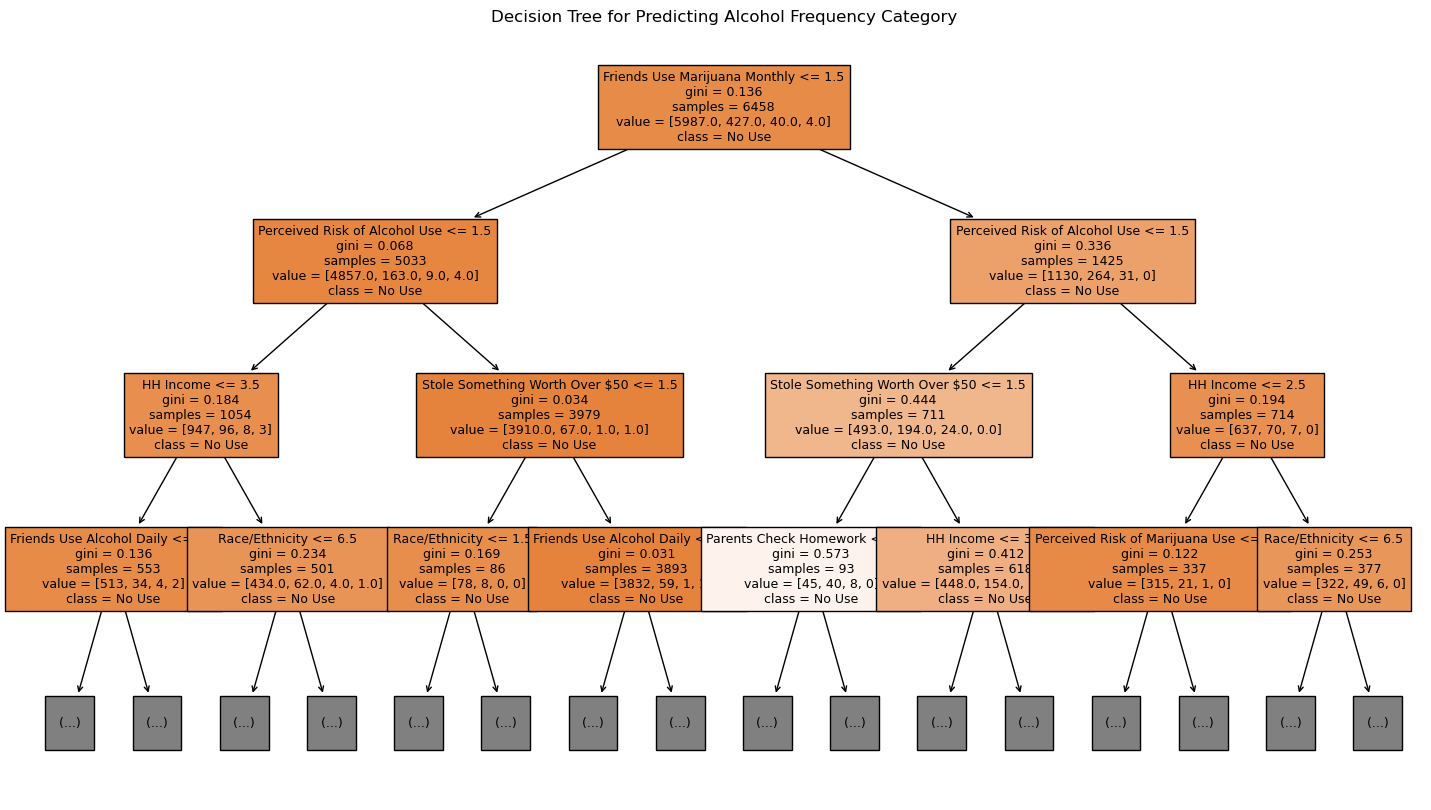

In [ ]:
# Plot the first few levels of the multi-class decision tree
plt.figure(figsize = (18, 10))
plot_tree(
    tree_multi,
    feature_names = feature_names,
    class_names = ['No Use', 'Low Use', 'Moderate Use', 'High Use'],
    filled = True,
    max_depth = 3,
    fontsize = 9
)

plt.title("Decision Tree for Predicting Alcohol Frequency Category")
plt.show()

### Gradient Boosting Model

In [ ]:
# Create a gradient boosting classifier
gb_clf = GradientBoostingClassifier(random_state = 1)

# Fit the model on the training data
gb_clf.fit(X_train, y_train)

GradientBoostingClassifier(random_state=1)

In [105]:
# Generate predictions on the test set
y_pred_gb = gb_clf.predict(X_test)

# Calculate accuracy
gb_acc = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", round(gb_acc, 4))

Gradient Boosting Accuracy: 0.922


In [106]:
# Create the confusion matrix
gb_cm = confusion_matrix(y_test, y_pred_gb)

print("Gradient Boosting Confusion Matrix:")
print(gb_cm)

Gradient Boosting Confusion Matrix:
[[2545   10    0    0]
 [ 180    8    0    0]
 [  19    2    0    0]
 [   5    0    0    0]]


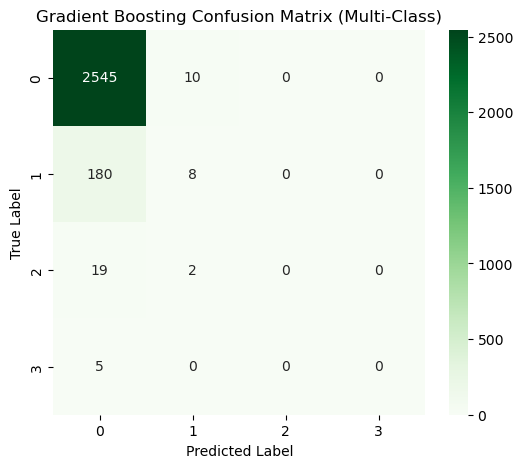

In [ ]:
# Plot the confusion matrix as a heatmap
plt.figure(figsize = (6, 5))
sns.heatmap(gb_cm, annot = True, fmt = 'd', cmap = 'Greens')

plt.title("Gradient Boosting Confusion Matrix (Multi-Class)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
# Extract feature importance values from gradient boosting
gb_importance = pd.Series(gb_clf.feature_importances_, index = X.columns)

# Sort from most to least important
gb_importance = gb_importance.sort_values(ascending = False)

print("Top 10 Most Important Features:")
print(gb_importance.head(10))

Top 10 Most Important Features:
FRDMJMON    0.371508
STNDALC     0.212570
YOSTOLE2    0.078689
INCOME      0.072538
STNDSMJ     0.062875
NEWRACE2    0.050895
FRDADLY2    0.030668
POVERTY3    0.027167
PRPROUD2    0.026290
PARCHKHW    0.018533
dtype: float64


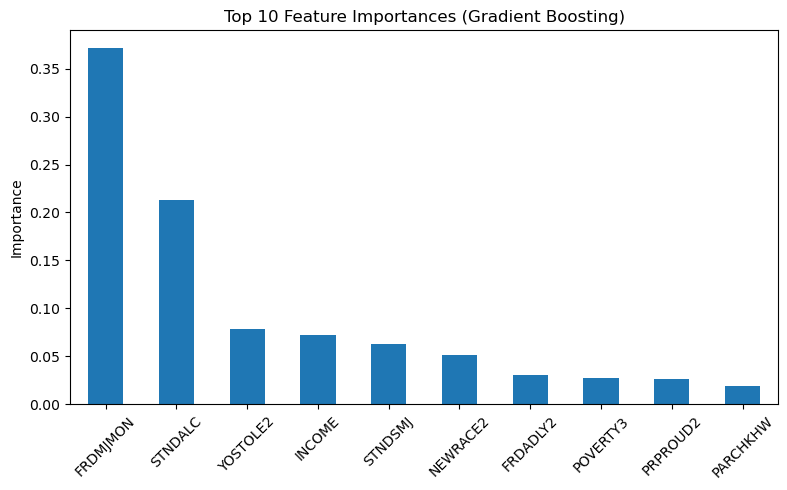

In [ ]:
# Plot top 10 feature importances
plt.figure(figsize = (8, 5))
gb_importance.head(10).plot(kind = 'bar')

plt.title("Top 10 Feature Importances (Gradient Boosting)")
plt.ylabel("Importance")
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

### Summary
- Although both models achieved high accuracy (approximately 0.89 for the decision tree and 0.92 for gradient boosting), accuracy represents the proportion of correct predictions and can be misleading in imbalanced datasets.
- The confusion matrices reveal that most predictions are concentrated in the "No Use" category, which is the majority class in the data. This means the models may be heavily influenced by class imbalance and tend to predict the most common outcome.
- As a result, the high accuracy does not necessarily indicate strong performance across all categories. While the models perform well at identifying non-users, they struggle to distinguish between low, moderate, and high levels of alcohol use among users.
- This highlights an important limitation of multi-class classification in imbalanced datasets: accuracy alone may overstate model performance and should be interpreted alongside the confusion matrix.

In [108]:
# Compare the two multi-class models
multi_comparison_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Gradient Boosting'],
    'Accuracy': [tree_multi_acc, gb_acc]
})

multi_comparison_df

,Model,Accuracy
0,Decision Tree,0.893824
1,Gradient Boosting,0.921993


## Regression Model
In this section, I predict the number of days a youth used alcohol in the past year using `IRALCFY` as the target variable. This variable represents a continuous measure of alcohol use frequency after recoding non-use values to 0.

I begin with a decision tree regressor as a baseline model and then compare it to a bagging regressor to evaluate whether an ensemble method improves predictive performance.

In [111]:
# Define predictors and regression target
X = model_data[predictors]
y_reg = model_data['IRALCFY']

In [ ]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size = 0.3, random_state=1
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (6458, 14)
Test set size: (2769, 14)


In [ ]:
# Create a decision tree regressor
tree_reg = DecisionTreeRegressor(random_state = 1)

# Fit the model
tree_reg.fit(X_train, y_train)

DecisionTreeRegressor(random_state=1)

In [114]:
# Predict on test set
y_pred_tree_reg = tree_reg.predict(X_test)

# Calculate RMSE
tree_mse = mean_squared_error(y_test, y_pred_tree_reg)
tree_rmse = np.sqrt(tree_mse)

print("Decision Tree RMSE:", round(tree_rmse, 4))

Decision Tree RMSE: 30.3277


### Bagging Model

In [ ]:
# Create a bagging regressor using decision trees
bag_reg = BaggingRegressor(
    estimator = DecisionTreeRegressor(),
    n_estimators = 100,
    random_state = 1
)

# Fit the model
bag_reg.fit(X_train, y_train)

BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=100,
                 random_state=1)

In [116]:
# Predict on test set
y_pred_bag = bag_reg.predict(X_test)

# Calculate RMSE
bag_mse = mean_squared_error(y_test, y_pred_bag)
bag_rmse = np.sqrt(bag_mse)

print("Bagging Regressor RMSE:", round(bag_rmse, 4))

Bagging Regressor RMSE: 22.6674


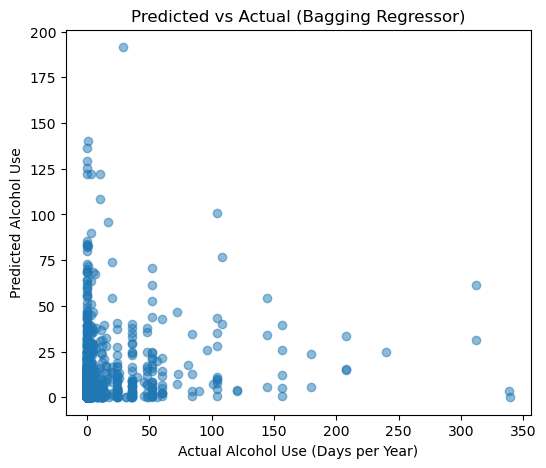

In [ ]:
plt.figure(figsize = (6, 5))
plt.scatter(y_test, y_pred_bag, alpha = 0.5)

plt.xlabel("Actual Alcohol Use (Days per Year)")
plt.ylabel("Predicted Alcohol Use")
plt.title("Predicted vs Actual (Bagging Regressor)")

plt.show()

In [ ]:
tree_reg_importance = pd.Series(tree_reg.feature_importances_, index = X.columns)
tree_reg_importance = tree_reg_importance.sort_values(ascending = False)

print("Top Features (Decision Tree Regressor):")
print(tree_reg_importance.head(10))

Top Features (Decision Tree Regressor):
NEWRACE2    0.187494
INCOME      0.112460
IRSEX       0.107288
PARHLPHW    0.080313
PARCHKHW    0.079854
POVERTY3    0.078940
PRPROUD2    0.065297
STNDSMJ     0.059792
YOFIGHT2    0.058178
STNDALC     0.050810
dtype: float64


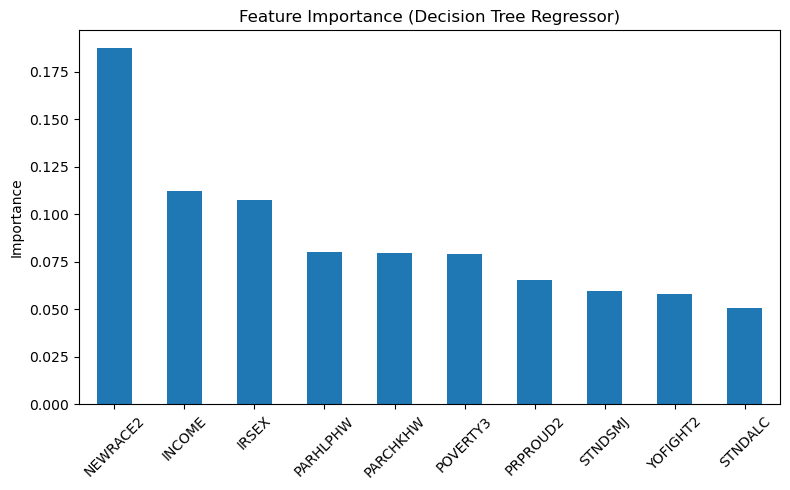

In [ ]:
plt.figure(figsize = (8, 5))
tree_reg_importance.head(10).plot(kind = 'bar')

plt.title("Feature Importance (Decision Tree Regressor)")
plt.ylabel("Importance")

plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

### Summary
- The decision tree regressor produced an RMSE of approximately 30.33, and the bagging regressor reduced the RMSE to approximately 22.67. RMSE represents the average prediction error in terms of the number of days alcohol was used in the past year.
    - This means that the decision tree model’s predictions were off by about 30 days on average, while the bagging model reduced this error to about 23 days.
- This reduction in RMSE suggests that ensemble methods are more effective for this regression task, as they reduce variance and produce more stable predictions compared to a single decision tree.
- Feature importance results from the decision tree regressor indicate that demographic, socioeconomic, family, and behavioral variables all play an important role in predicting alcohol use frequency. These findings are consistent with the other classification models, suggesting that similar factors influence both whether youth use alcohol and how frequently they use it.

In [121]:
reg_comparison_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Bagging Regressor'],
    'RMSE': [tree_rmse, bag_rmse]
})

reg_comparison_df

,Model,RMSE
0,Decision Tree,30.327748
1,Bagging Regressor,22.667425


## Model Comparison and Discussion

In [127]:
summary_df = pd.DataFrame({
    'Task': ['Binary Classification', 'Multi-Class Classification', 'Regression'],
    'Baseline Model': ['Decision Tree', 'Decision Tree', 'Decision Tree'],
    'Ensemble Model': ['Random Forest', 'Gradient Boosting', 'Bagging'],
    'Baseline Performance': [tree_acc, tree_multi_acc, tree_rmse],
    'Ensemble Performance': [rf_acc, gb_acc, bag_rmse]
})

summary_df

,Task,Baseline Model,Ensemble Model,Baseline Performance,Ensemble Performance
0,Binary Classification,Decision Tree,Random Forest,0.755146,0.767064
1,Multi-Class Classification,Decision Tree,Gradient Boosting,0.893824,0.921993
2,Regression,Decision Tree,Bagging,30.327748,22.667425


### Interpretation
- Several patterns were consistent across the models:
    - Peer-related variables were repeatedly important predictors, suggesting that social environment is strongly associated with youth alcohol use.
    - Perceived risk of alcohol and marijuana also appeared important, indicating that attitudes toward substances may influence behavior.
    - Family variables such as parental support and homework involvement were also among the important predictors, which suggests that family environment may play a protective role.
    - In addition, socioeconomic variables such as household income and poverty were consistently relevant, indicating that alcohol use is associated with broader environmental factors as well.
- When we look at the patterns together, the results of this analysis suggest that youth alcohol use is not explained by a single factor. Instead, it appears to reflect a combination of peer influence, family context, attitudes toward substance use, and socioeconomic conditions.

### Summary of Model Performance
- The table above summarizes the results across the three prediction tasks. Ensemble methods outperformed single decision trees in all cases.
- Random forest slightly improved the binary classification accuracy ($\approx$ 0.7671) over the baseline ($\approx$ 0.7551).
- Gradient boosting improved the multi-class classification accuracy ($\approx$ 0.922) over the base line ($\approx$ 0.938).
- Bagging significantly redused regression error ($\approx$ 22.67) over the baseline ($\approx$ 30.33).
- The strongest improvement appeared in the regression task, where RMSE decreased from about 30.33 to 22.67.
    - This suggests that averaging across multiple trees was especially helpful when predicting a continuous outcome.

### Effect of Variable Type on Prediction
- One important feature of this dataset is that alcohol use can be represented in multiple ways:
    - Binary (`ALCFLAG`): Wheter or not the respondent has ever used alcohol.
        - This gives the most simple prediction problem, It only asks whether a youth has ever used alcohol, becasue of this it collapses many different patterns of behavior into two groups. Overall, this makes the problem easier to model and interpret, but it does lose information about frequency or intensity of use.
    - Categorical (`ALC_FREQ_CAT`): Grouped into levels of alcohol use frequency in the past month.
        - This adds more detail by separating youth into no use, low use, moderate use, high use groups. Since there are more groups, it gives a richer picture of alcohol behavior, but it also makes a more difficult classification problem. In this analysis the multi-class models achieved high overall accuracy, but a lot of that performance came from correctly identifying the majority of the "No Use" category.
    - Numeric (`IRALCFY`): The Number of days alcohol was used in the past year.
        - The numeric target gives us the most detailed representation because it preserves the number of alcohol use in the past year. This is appropriate when the goal is to estimate intensity of use rather than simply classify respondents into categories. However, regression is also more challenging because the model must predict a wide range of possible values rather than assign one of a few classes.

### Comparison of Tree-based Models
- Across all three tasks, ensemble methods improved performance over single decision trees. This is in line with the theory that single trees are easy to interpret but can have high variance, while ensemble methosd reduce variance bu combining many trees.
    - For binary classification, random forest only slightly improved accuracy over the single decision tree. This suggests that the simpler tree already captured much of the signal in the data, though the random forest still provided a modest gain.
    - For multi-class, gradient boosting achieved the highest accuracy. However, the confusion matrix showed that the model overwhelmingly predicted the majority class. This means the improvement in accuracy should not be interpreted as equally strong performance across all frequency categories.
    - For regression, bagging produced a much larger improvement than the classification ensembles. This suggests that ensemble averaging was especially helpful for stabilizing predictions of yearly alcohol use.
- In terms of interpretation, single trees are easier to visualize and explain, which makes them useful as baseline models and presentation tools. Ensemble methods are generally stronger predictors, but they are less interpretable because they combine information across many trees.

### Limitations
- This analysis currently has several limitations.
    - First, the multi-class target was highly imbalanced, with most respondents falling into the "No Use" category. This made overall accuracy less informative and limited the models' ability to distinguish between low, moderate, and high use categories.
    - Second, the predictor set was intentionally limited to a smaller group of variables for interpretability. While this made the models easier to explain, it may have excluded other important predictors related to mental health, education, or youth experiences.
    - Third, although tree-based models identify associations, they do not establish causation. Variables such as race/ethnicity, income, and family characteristics should be interpreted as correlated with alcohol use, not as direct causes.

- Potential improvements could include:
    - Addressing class imbalance through resampling or class-weighted methods.
    - Tuning hyperparameters more extensively.
    - Including additional relevant predictors from the broader dataset.
    - Comparing tree-based models to non-tree models for a broader benchmark